# 05 · Exploratory: exit events, mechanism and decay (post-verdict)

**ORB study, notebook 5 of 5. Exploratory, run after the verdict was frozen; nothing here changes it.** All 46
policies and the controls were run on every block for both assets (PREREGISTRATION.md section 10). Any pattern
picked out of these tables is a hypothesis for a new pre-registration with data not yet seen, not a finding: with
54 rules × 2 assets × 3 blocks, some cells will look good by chance.

In [1]:
import json, subprocess, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

STUDY = Path.cwd()
assert (STUDY / "PREREGISTRATION.md").exists(), "execute from studies/notebooks/orb_study"
sys.path.insert(0, str(STUDY))
import orb_calendars as cal, orb_checks, orb_data, orb_engine as eng, orb_metrics as met, orb_policies as pol
from review_plots import AXIS, INK2, MUTED, NEGATIVE, NEUTRAL, SERIES, style, zero_line
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 80)
RESULTS = STUDY / "results"

X = RESULTS / "run_v1/exploratory"
A = pd.read_csv(X / "all_policies.csv")
Y = pd.read_csv(X / "by_year.csv")
MECH = json.loads((X / "mechanism.json").read_text())
DIAG = json.loads((X / "diagnostics.json").read_text())
EXC = pd.read_csv(X / "excursions_BTCUSDT_P0.csv")
BLOCKS = ["development", "validation", "lockbox"]
ORDER = [p.id for p in (*pol.FAMILY, *pol.CONTROLS)]

def pivot(sym, scenario="gross", value="mean_bp"):
    tab = A[(A.symbol == sym) & (A.scenario == scenario)].pivot_table(index="policy", columns="block", values=value)[BLOCKS]
    return tab.loc[ORDER]

## 1. By year: BTC never cleared its costs outside 2022

P0's gross expectancy per calendar year. The grey line is the 11.6 bp round trip. Outside 2022, BTC's gross stayed
between −1.5 and +8.8 bp in every year and was lower after the US spot-ETF launch; ETH cleared the cost line in
2022, 2025 and 2026.

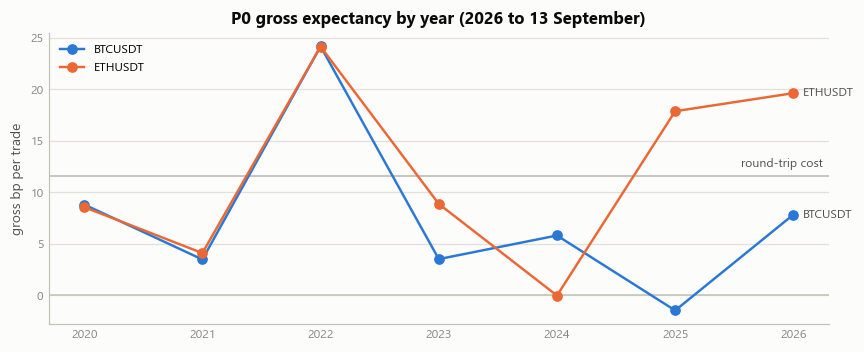

BTC P0 before / after the US spot-ETF launch: {'pre_etf': {'trades': 984, 'gross_bp': 9.954641323005312, 'db_bp': -1.5161708574109476}, 'post_etf': {'trades': 657, 'gross_bp': 3.645802973700107, 'db_bp': -7.913606451164225}}


In [2]:
fig, ax = plt.subplots(figsize=(8, 3.3))
for i, sym in enumerate(("BTCUSDT", "ETHUSDT")):
    s = Y[(Y.symbol == sym) & (Y.policy == "P0") & (Y.scenario == "gross")].set_index("year")["mean_bp"]
    ax.plot(s.index.astype(str), s.values, marker="o", color=SERIES[i], label=sym)
    ax.annotate(sym, xy=(len(s) - 1, s.values[-1]), xytext=(6, 0), textcoords="offset points", fontsize=8, color=INK2, va="center")
style(ax); zero_line(ax); zero_line(ax, 11.6, "round-trip cost", color=NEUTRAL)
ax.set_ylabel("gross bp per trade"); ax.set_title("P0 gross expectancy by year (2026 to 13 September)"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()
print("BTC P0 before / after the US spot-ETF launch:", {k: DIAG["BTCUSDT_P0"][k] for k in ("pre_etf", "post_etf")})

## 2. Mechanism: most of the gross is not the breakout's direction

For each block: P0's gross, the median of 200 random-direction versions of the same trades (same entry, same stop
distance, coin-flip side) and the median of 200 random-time versions. On a random walk all three are about zero
(engine check at the end of this section). On real BTC and ETH the random versions earn a positive gross in every
block, so much of what the rule earns comes from its shape: a stop at the range edge held into the US session
profits from intraday momentum whichever way the position faces. The breakout's own contribution is the gap between
P0 and the random-direction median: positive in 2020–22, negative in 2023–24, mixed since.

,asset,block,P0,random direction (median),random time (median),share of direction seeds >= P0
0,BTCUSDT,development,12.10,6.58,1.67,0.12
1,BTCUSDT,validation,4.68,10.69,7.68,0.90
2,BTCUSDT,lockbox,2.41,5.70,2.90,0.74
3,ETHUSDT,development,12.18,8.00,3.01,0.20
4,ETHUSDT,validation,4.38,9.89,5.74,0.78
5,ETHUSDT,lockbox,18.59,11.41,6.03,0.22


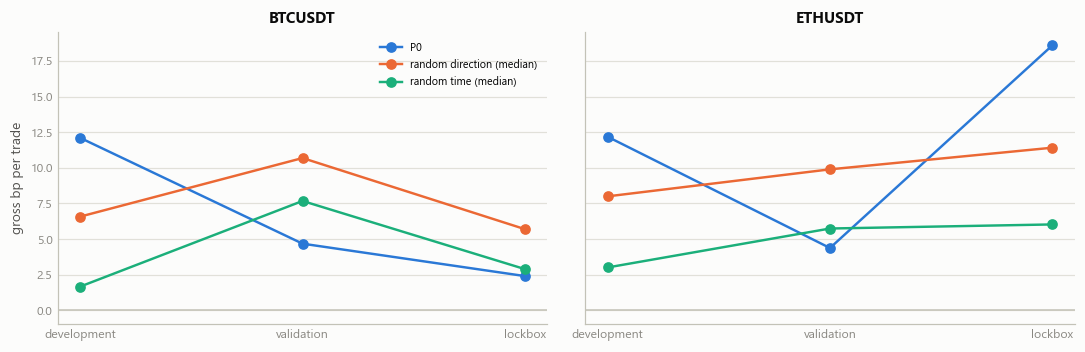

random-walk engine check (gross bp, synthetic market):


,trades,gross_mean_bp,se_bp
CTL_CLOCK_LONG,1670.0,0.97,1.11
CTL_CLOCK_SHORT,1670.0,1.49,1.16
P0,1668.0,2.33,1.58


In [3]:
rows = []
for sym in ("BTCUSDT", "ETHUSDT"):
    for b in BLOCKS:
        m = MECH[f"{sym}_{b}"]
        rows.append({"asset": sym, "block": b, "P0": m["p0_gross_bp"], "random direction (median)": m["random_direction_gross_median_bp"],
                     "random time (median)": m["random_time_gross_median_bp"], "share of direction seeds >= P0": m["random_direction_share_ge_p0"]})
M = pd.DataFrame(rows)
display(M.round(2))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3), sharey=True)
for ax, sym in zip(axes, ("BTCUSDT", "ETHUSDT")):
    m = M[M.asset == sym]
    for i, col in enumerate(("P0", "random direction (median)", "random time (median)")):
        ax.plot(m.block, m[col], marker="o", color=SERIES[i], label=col)
    style(ax); zero_line(ax); ax.set_title(sym, fontsize=10)
axes[0].set_ylabel("gross bp per trade"); axes[0].legend(loc="upper right", fontsize=7)
plt.tight_layout(); plt.show()
print("random-walk engine check (gross bp, synthetic market):")
pd.DataFrame(MECH["random_walk_engine_check"]).T.round(2)

## 3. Anchors across all blocks

Mean gross over the four range lengths and both entries, per anchor, and the placebo shifts of P0. The NY anchor had
the highest mean gross in five of six asset-blocks (the exception is BTC 2025–26, where every anchor was within a few
bp of zero); midnight UTC was negative in every block after 2022; and the placebo shifted two hours earlier (07:30
New York) was the lowest or second-lowest of the five shifts in every block.

In [4]:
out = {}
for sym in ("BTCUSDT", "ETHUSDT"):
    g = pivot(sym)
    for anchor in ("NY", "LDN", "UTC"):
        ids = [i for i in g.index if i.startswith(f"CORE_{anchor}_")] + (["P0"] if anchor == "NY" else [])
        out[(sym, f"{anchor} (mean of 8 policies)")] = g.loc[ids].mean()
    for pid in ("CTL_PLACEBO_M120", "CTL_PLACEBO_M60", "P0", "CTL_PLACEBO_P60", "CTL_PLACEBO_P120"):
        out[(sym, pid)] = g.loc[pid]
pd.DataFrame(out).T.round(1)

block                             development  validation  lockbox
BTCUSDT NY (mean of 8 policies)          14.5        15.4      3.8
        LDN (mean of 8 policies)         -0.5         1.5      5.1
        UTC (mean of 8 policies)          0.4        -3.5     -3.8
        CTL_PLACEBO_M120                 -8.9         1.2     -0.6
        CTL_PLACEBO_M60                  -4.1        -2.6      6.5
        P0                               12.1         4.7      2.4
        CTL_PLACEBO_P60                   7.2         6.0      5.7
        CTL_PLACEBO_P120                 -1.0         7.6     -1.7
ETHUSDT NY (mean of 8 policies)          14.1        12.9     19.8
        LDN (mean of 8 policies)          6.3         3.4      6.6
        UTC (mean of 8 policies)          2.7        -2.7     -3.5
        CTL_PLACEBO_M120                -16.0       -10.6      0.4
        CTL_PLACEBO_M60                  -7.9        -2.9     12.6
        P0                               12.2         4.4     18.6
        CTL_PLACEBO_P60                   5.9         3.1     12.6
        CTL_PLACEBO_P120                  0.6         9.3      5.5

## 4. Exit events across every block

Each arm changes only P0's exit. Across the six asset-blocks (BTC and ETH, three periods each): fixed 1R/2R/3R
targets, the 60-minute exit and the trailing stop had a lower gross than P0 in all six; the VWAP-cross exit in five;
the close-back-inside-the-range exits (1-minute and 15-minute) and the midpoint stop in four, beating P0 only in the
two blocks where P0's own gross had almost vanished (BTC 2025–26, ETH 2023–24). None of these earlier exits was net
positive after costs in more than one block. Removing the 16:00 exit raised the gross in four of six (all three BTC
blocks and ETH 2025–26), at the price of a win rate near 10% and a large drawdown.

In [5]:
arms = ["X_NOTIME", "EXT_TGT3R", "EXT_TGT2R", "EXT_TGT1R", "X_VWAP", "X_REENTER15M", "X_REENTER1M", "X_TRAIL", "X_TRAIL_NOTIME", "EXT_TX60", "EXT_STOPMID"]
G = A[A.scenario == "gross"].pivot_table(index=["symbol", "block"], columns="policy", values="mean_bp")
N = A[A.scenario == "db"].pivot_table(index=["symbol", "block"], columns="policy", values="mean_bp")
pd.DataFrame([{"exit arm": k, "blocks with gross above P0 (of 6)": int((G[k] > G["P0"]).sum()),
               "blocks net positive (of 6)": int((N[k] > 0).sum()), "mean gross minus P0, bp": (G[k] - G["P0"]).mean()} for k in arms]).round(2)

,exit arm,blocks with gross above P0 (of 6),blocks net positive (of 6),"mean gross minus P0, bp"
0,X_NOTIME,4,3,10.82
1,EXT_TGT3R,0,1,-3.68
2,EXT_TGT2R,0,0,-5.60
3,EXT_TGT1R,0,0,-10.04
4,X_VWAP,1,0,-6.94
5,X_REENTER15M,2,0,-3.94
6,X_REENTER1M,2,0,-4.69
7,X_TRAIL,0,0,-6.42
8,X_TRAIL_NOTIME,1,0,-6.47
9,EXT_TX60,0,0,-8.17


BTCUSDT


block,development gross,validation gross,lockbox gross,development net,validation net,lockbox net,development win,validation win,lockbox win,development maxDD,validation maxDD,lockbox maxDD
policy,,,,,,,,,,,,
P0,12.10,4.68,2.41,0.65,-6.84,-9.17,0.34,0.30,0.33,-0.35,-0.37,-0.39
X_NOTIME,32.74,10.54,14.59,17.93,-1.67,2.58,0.10,0.09,0.15,-0.72,-0.56,-0.38
EXT_TGT3R,8.35,3.00,-0.03,-3.09,-8.52,-11.62,0.37,0.33,0.33,-0.37,-0.39,-0.43
EXT_TGT2R,6.56,1.13,0.20,-4.92,-10.39,-11.38,0.40,0.38,0.36,-0.48,-0.44,-0.43
EXT_TGT1R,3.41,-0.70,-5.20,-8.17,-12.24,-16.79,0.54,0.51,0.45,-0.49,-0.48,-0.53
X_VWAP,4.63,-2.20,-0.95,-6.94,-13.79,-12.54,0.23,0.21,0.21,-0.46,-0.50,-0.44
X_REENTER15M,4.14,-0.77,5.33,-7.42,-12.35,-6.26,0.16,0.14,0.16,-0.56,-0.48,-0.28
X_REENTER1M,1.79,0.15,4.00,-9.78,-11.46,-7.59,0.08,0.07,0.09,-0.53,-0.47,-0.32
X_TRAIL,1.99,-2.57,1.30,-9.56,-14.16,-10.29,0.32,0.33,0.31,-0.52,-0.51,-0.42


ETHUSDT


block,development gross,validation gross,lockbox gross,development net,validation net,lockbox net,development win,validation win,lockbox win,development maxDD,validation maxDD,lockbox maxDD
policy,,,,,,,,,,,,
P0,12.18,4.38,18.59,0.56,-7.15,6.97,0.33,0.29,0.36,-0.54,-0.39,-0.25
X_NOTIME,3.85,3.22,54.34,-11.85,-8.57,42.40,0.09,0.09,0.16,-0.84,-0.55,-0.33
EXT_TGT3R,8.64,0.55,11.73,-2.96,-10.98,0.13,0.36,0.31,0.37,-0.45,-0.47,-0.30
EXT_TGT2R,3.52,-0.30,9.66,-8.11,-11.84,-1.95,0.39,0.36,0.39,-0.52,-0.49,-0.30
EXT_TGT1R,1.62,-1.99,-3.07,-9.97,-13.55,-14.67,0.52,0.51,0.48,-0.64,-0.50,-0.51
X_VWAP,4.48,5.49,1.26,-7.10,-6.12,-10.34,0.23,0.21,0.22,-0.46,-0.29,-0.45
X_REENTER15M,8.76,5.05,8.20,-2.79,-6.58,-3.41,0.17,0.16,0.15,-0.33,-0.34,-0.29
X_REENTER1M,6.23,5.28,8.76,-5.42,-6.32,-2.85,0.09,0.09,0.10,-0.38,-0.28,-0.27
X_TRAIL,7.53,-1.64,9.22,-4.11,-13.22,-2.39,0.34,0.31,0.33,-0.38,-0.49,-0.31


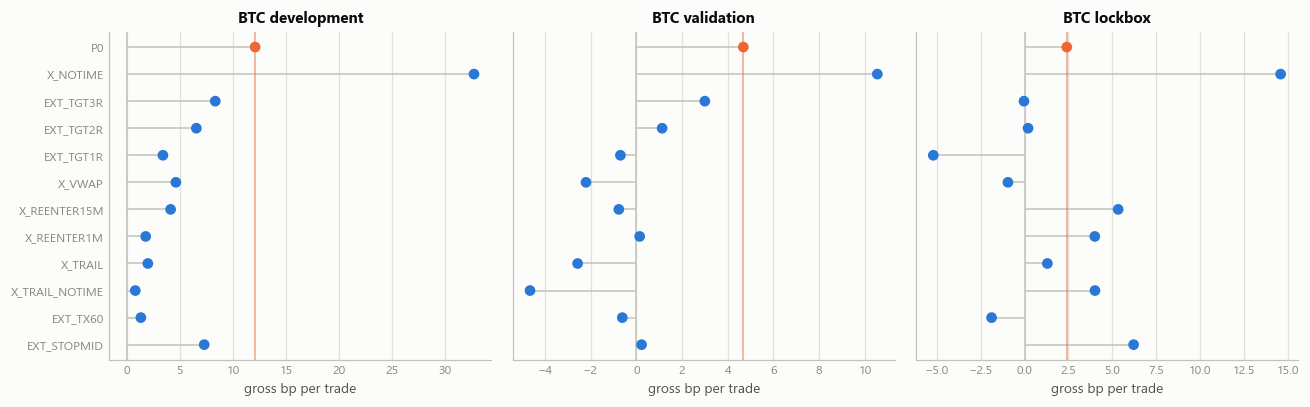

In [6]:
exit_ids = ["P0", "X_NOTIME", "EXT_TGT3R", "EXT_TGT2R", "EXT_TGT1R", "X_VWAP", "X_REENTER15M", "X_REENTER1M", "X_TRAIL", "X_TRAIL_NOTIME", "EXT_TX60", "EXT_STOPMID"]
for sym in ("BTCUSDT", "ETHUSDT"):
    tab = pivot(sym).loc[exit_ids].add_suffix(" gross").join(pivot(sym, "db").loc[exit_ids].add_suffix(" net"))
    tab = tab.join(pivot(sym, "db", "win_rate").loc[exit_ids].add_suffix(" win")).join(pivot(sym, "db", "max_drawdown").loc[exit_ids].add_suffix(" maxDD"))
    print(sym); display(tab.round(2))
g = pivot("BTCUSDT").loc[exit_ids]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
yy = np.arange(len(exit_ids))[::-1]
for ax, b in zip(axes, BLOCKS):
    ax.hlines(yy, 0, g[b], color=AXIS, linewidth=1)
    ax.scatter(g[b], yy, color=[SERIES[1] if k == "P0" else SERIES[0] for k in exit_ids], s=36, zorder=3)
    ax.axvline(g.loc["P0", b], color=SERIES[1], linewidth=1, alpha=0.6)
    style(ax, grid_axis="x"); ax.axvline(0, color=AXIS, linewidth=1); ax.set_title(f"BTC {b}", fontsize=10); ax.set_xlabel("gross bp per trade")
axes[0].set_yticks(yy); axes[0].set_yticklabels(exit_ids, fontsize=8)
plt.tight_layout(); plt.show()

## 5. What the stop and the 16:00 exit do to P0's trades (BTC, 2020–2026)

Stopped trades are decided early: their best moment comes a median 8 minutes after entry, and a quarter of them were
at least 1R in profit before the stop. Trades still open at 16:00 peaked a median three hours after entry and had given
back a median 80 bp by the exit. After the 16:00 exit, the next four hours show no consistent follow-through.

In [7]:
EXC["block"] = np.where(EXC.date < "2023-01-01", "development", np.where(EXC.date < "2025-01-01", "validation", "lockbox"))
EXC["mfe_R"] = EXC.mfe_bp / EXC.risk_bp
display(EXC.groupby("exit_reason").agg(trades=("gross_bp", "size"), mean_gross_bp=("gross_bp", "mean"), median_mfe_bp=("mfe_bp", "median"),
                                       median_minutes_to_best=("minutes_to_mfe", "median"), median_gave_back_bp=("gave_back_bp", "median"),
                                       share_reaching_1R=("mfe_R", lambda r: (r >= 1).mean())).round(2))
EXC[EXC.exit_reason == "time"].groupby("block")[["move_after_4h_bp", "move_after_12h_bp", "move_after_24h_bp"]].agg(["mean", "median"]).round(1)

,trades,mean_gross_bp,median_mfe_bp,median_minutes_to_best,median_gave_back_bp,share_reaching_1R
exit_reason,,,,,,
stop,976,-77.20,30.00,8.0,103.84,0.25
time,665,131.64,183.09,186.0,79.78,0.83


move_after_4h_bp        move_after_12h_bp        move_after_24h_bp       
                        mean median              mean median              mean median
block                                                                                
development              6.4    3.0              16.7    9.4              37.1   -2.3
lockbox                 -4.2   -1.0              -3.6  -20.3              11.2    6.5
validation              -3.6  -19.4               5.5  -16.5              -2.8  -18.9

## 6. Diagnostics for P0, the challenger and the no-time-exit arm

Long and short, before and after the US spot-ETF launch (2024-01-11), range-width and relative-volume terciles, the
share of all gross carried by the best 20 trades, the break-even round trip, and the relationship to simply holding
the perpetual.

In [8]:
rows = []
for key, dd in DIAG.items():
    if "long" not in dd:
        continue
    rows.append({"series": key, "long_gross": dd["long"]["gross_bp"], "short_gross": dd["short"]["gross_bp"], "pre_etf_gross": dd["pre_etf"]["gross_bp"],
                 "post_etf_gross": dd["post_etf"]["gross_bp"], "narrow_width_gross": dd["width_terciles"]["low"]["gross_bp"],
                 "wide_width_gross": dd["width_terciles"]["high"]["gross_bp"], "low_relvol_gross": dd["relvol_terciles"]["low"]["gross_bp"],
                 "high_relvol_gross": dd["relvol_terciles"]["high"]["gross_bp"], "best20_share_of_gross": dd["best_trade_share_of_gross"]["20"],
                 "break_even_rt_bp": dd["break_even_rt_bp"], "beta_vs_hold": dd["beta_vs_calendar_hold"], "corr_vs_hold": dd["corr_vs_calendar_hold"]})
display(pd.DataFrame(rows).set_index("series").round(2))
print({k: v for k, v in DIAG.items() if "early_close" in k})

,long_gross,short_gross,pre_etf_gross,post_etf_gross,narrow_width_gross,wide_width_gross,low_relvol_gross,high_relvol_gross,best20_share_of_gross,break_even_rt_bp,beta_vs_hold,corr_vs_hold
series,,,,,,,,,,,,
BTCUSDT_P0,6.76,8.04,9.95,3.65,13.67,0.05,7.89,8.03,1.06,7.52,-0.00,-0.00
BTCUSDT_EXT_WIDTH,3.26,15.84,15.67,1.27,10.90,4.29,3.30,22.53,1.14,9.89,-0.02,-0.10
BTCUSDT_X_NOTIME,39.04,5.82,16.53,30.11,30.79,4.37,-9.56,27.72,2.02,19.74,-0.04,-0.05
ETHUSDT_P0,12.65,10.45,11.04,12.17,18.57,3.44,21.31,-0.79,0.89,11.50,-0.00,-0.00
ETHUSDT_EXT_WIDTH,11.97,14.99,16.87,8.99,14.88,2.83,24.98,6.64,1.16,13.53,-0.01,-0.03
ETHUSDT_X_NOTIME,27.24,2.72,-2.33,44.97,34.72,-40.03,38.71,-30.13,3.32,12.23,-0.05,-0.07


{'BTCUSDT_P0_early_close_sessions': {'trades': 11, 'gross_bp': -10.946463326548765}, 'ETHUSDT_P0_early_close_sessions': {'trades': 12, 'gross_bp': -55.105326167260664}}


## 7. Hypotheses this leaves (not findings)

- **US-session intraday momentum, not ORB.** The random controls, the anchor comparison and the placebo shifts point
  at the same thing: positions held from the US open into the US afternoon, with a stop at the opening range, earned
  gross returns whichever way they faced. That is a different hypothesis — intraday momentum around the US session —
  and would need its own mechanism statement, pre-registration and data not yet seen.
- **Costs are the wall.** BTC P0's break-even round trip is 7.5 bp, below the 10 bp taker-fee floor. Anything in this
  family needs maker entries or a much larger gross per trade.
- **For breakout payoffs, cut on the structural stop only.** Invalidation exits on the first close back inside the
  range and trailing stops removed the trades that pay; dropping the time exit raised gross but turned the rule into a
  trend-following position with a win rate near 10%. This agrees with the repository's earlier lessons (wider targets
  beat tight ones on the same stop; tight trailing stops hurt). It says nothing directly about mean-reversion trades
  such as squeeze_bull, whose exits are the exit-policy study's job.